# Compare sv_loss vs pareto vs roa, full FDSI benchmark

RoA across all 100 recordings for the three showcased searches, each applied to the full
benchmark, plus the shared `fixed` (no-adaptation) baseline:

| branch | sampler | search |
|---|---|---|
| `sv_loss` | `tpe_sv_median` | single-objective `sv_loss`, current median aggregation |
| `pareto` | `tpe_pareto` | Pareto `(wh_loss, sv_loss)`, current median aggregation |
| `roa` | `tpe_roa` | single-objective `roa` (ground-truth-informed, upper-bound reference) |

Pure disk read -- this notebook runs no new decomposition or search, only
`rate_of_agreement_paired` against each already-saved `AdaptationResult.spikes` (via
`fdsi_common.aggregate_roa_from_disk`). Adapted from
`notebooks/muniverse_simulations/fdsi_38_compare_28_36_37.ipynb`'s structure, re-pointed at
this showcase's three *current* branches instead of the historical 28/36/37 trio -- see
`notebooks/muniverse_simulations/summary_ablation_and_comparison.ipynb` for that original
comparison, kept as a personal-reference record.

## Config

In [1]:
import yaml
from pathlib import Path

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

FDSI_ROOT = Path(grid['fdsi_root'])
DATA_DIR, CAL_DIR, ADAPT_DIR = FDSI_ROOT / 'data', FDSI_ROOT / 'calibration', FDSI_ROOT / 'adaptation'
OPT_DIR = ADAPT_DIR / 'optimisation'

FS, EXT_FACT = grid['fs'], grid['ext_fact']
TOL_SPIKE_MS, ROA_CAL_TH = grid['tol_spike_ms'], grid['roa_cal_th']
CAL_END, ISO_DUR = int(grid['cal_duration_s'] * FS), int(grid['iso_duration_s'] * FS)

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]

POOL_CONDITIONS = grid['pool_conditions']
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]
OPTIM_SUB, OPTIM_SNR, N_TRIALS = grid['optim_sub'], grid['optim_snr'], grid['n_trials']

BASE_CONFIG_DIR = Path('../../configs/adapt_configs')
BASE_CONFIG_PATH = BASE_CONFIG_DIR / 'default_muniverse.yaml'   # wh_sv_coupling=True; lr_mode overridden per branch below
LR_TOKEN_TO_MODE = {'lr_fixed': 'fixed', 'lr_relerror': 'rel_error'}

print(f'Apply-to-all grid: {len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} recordings')

Apply-to-all grid: 5 subjects x 5 conditions x 4 SNR levels = 100 recordings


In [2]:
import sys
sys.path.insert(0, '../..')
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import fdsi_common as fc

sns.set_theme(style='whitegrid', font_scale=1.1)

# (sampler dir, branch label) -- each applied to all 100 recordings, both lr_modes
SAMPLERS = [('tpe_sv_median', 'sv_loss'), ('tpe_pareto', 'pareto'), ('tpe_roa', 'roa')]

## Aggregate RoA from disk

`fixed` plus 3 branches x 2 `lr_mode`s = 7 configs total.

In [3]:
CONFIG_LABELS = [('fixed', None, None)]
for lr_mode in ('fixed', 'rel_error'):
    lr_token = fc.LR_MODE_TOKEN[lr_mode]
    for sampler_name, branch in SAMPLERS:
        CONFIG_LABELS.append((f'{lr_token}_{sampler_name} ({branch})', lr_mode, sampler_name))
CONFIG_ORDER = [c for c, _, _ in CONFIG_LABELS]

df_roa = fc.aggregate_roa_from_disk(ADAPT_DIR, CAL_DIR, DATA_DIR, SUBJECTS, CONDITIONS, SNR_LEVELS,
                                     CONFIG_LABELS, FS, TOL_SPIKE_MS)
df_roa['roa_pct'] = df_roa['roa'] * 100
configs_present = [c for c in CONFIG_ORDER if c in df_roa['config'].unique()]
print(f'{len(df_roa)} (recording, unit, config) rows aggregated.')
print('configs present:', configs_present)

5376 (recording, unit, config) rows aggregated.
configs present: ['fixed', 'lr_fixed_tpe_sv_median (sv_loss)', 'lr_fixed_tpe_pareto (pareto)', 'lr_fixed_tpe_roa (roa)', 'lr_relerror_tpe_sv_median (sv_loss)', 'lr_relerror_tpe_pareto (pareto)', 'lr_relerror_tpe_roa (roa)']


## Overall summary

In [4]:
overall = df_roa.groupby('config')['roa_pct'].agg(
    ['count', 'mean', 'median', lambda x: (x >= 90).sum() / len(x) * 100]
).round(2)
overall.columns = ['n_unit_rows', 'mean_roa_pct', 'median_roa_pct', 'pct_units_roa_ge_90']
overall = overall.reindex(configs_present)
overall

,n_unit_rows,mean_roa_pct,median_roa_pct,pct_units_roa_ge_90
config,,,,
fixed,768,37.58,34.76,0.00
lr_fixed_tpe_sv_median (sv_loss),768,72.69,84.94,44.27
lr_fixed_tpe_pareto (pareto),768,79.25,95.03,57.68
lr_fixed_tpe_roa (roa),768,84.30,96.99,68.49
lr_relerror_tpe_sv_median (sv_loss),768,73.32,87.99,47.27
lr_relerror_tpe_pareto (pareto),768,73.40,87.49,46.48
lr_relerror_tpe_roa (roa),768,77.90,93.12,55.60


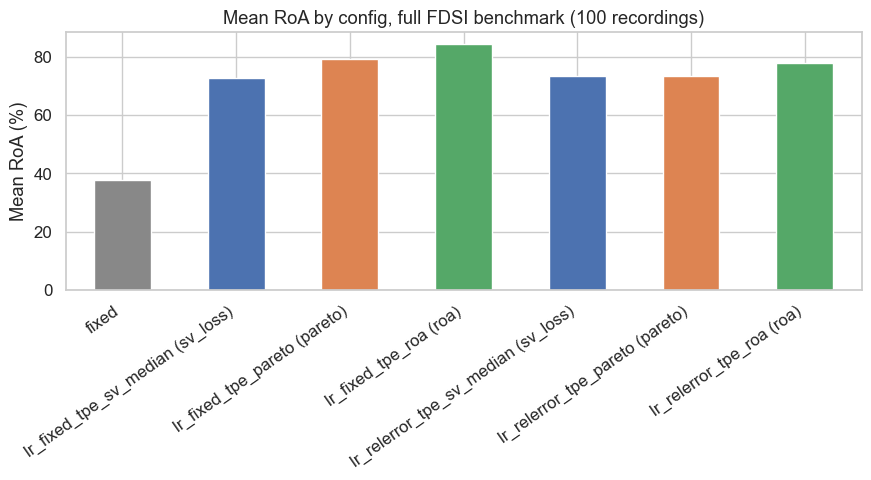

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#888888'] + ['#4C72B0', '#DD8452', '#55A868'] * 2
overall['mean_roa_pct'].plot.bar(ax=ax, color=colors[:len(overall)])
ax.set(ylabel='Mean RoA (%)', xlabel='', title='Mean RoA by config, full FDSI benchmark (100 recordings)')
ax.tick_params(axis='x', rotation=35)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

## By condition and by SNR

In [6]:
by_cond = (df_roa.groupby(['condition', 'config'])['roa_pct'].mean().unstack('config')
           .reindex(index=CONDITIONS, columns=configs_present))
by_cond.round(2)

config,fixed,lr_fixed_tpe_sv_median (sv_loss),lr_fixed_tpe_pareto (pareto),lr_fixed_tpe_roa (roa),lr_relerror_tpe_sv_median (sv_loss),lr_relerror_tpe_pareto (pareto),lr_relerror_tpe_roa (roa)
condition,,,,,,,
staircase,33.59,83.95,91.64,94.99,79.98,80.37,90.52
triangular-ramp40s,38.15,76.85,87.45,92.17,78.26,77.98,86.40
triangular-ramp20s,39.28,73.84,81.02,90.95,76.70,76.14,84.20
triangular-ramp10s,38.48,66.74,72.06,76.94,66.53,67.04,68.13
triangular-ramp5s,38.45,62.13,64.17,66.76,65.29,65.58,60.54


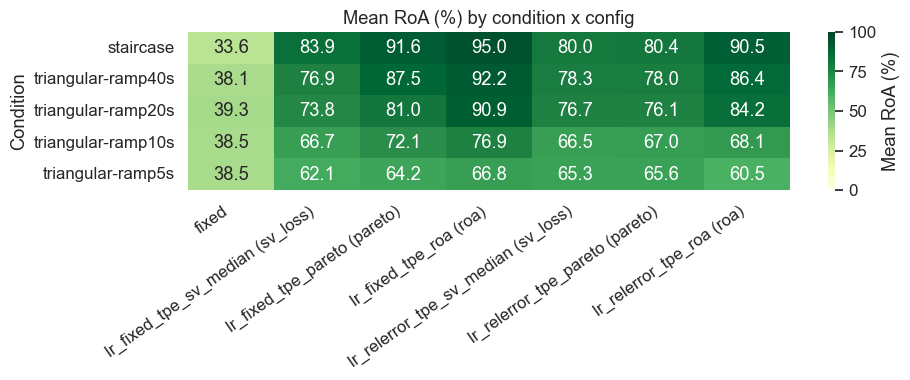

In [7]:
fig, ax = plt.subplots(figsize=(1.1 * len(configs_present) + 2, 4))
sns.heatmap(by_cond, annot=True, fmt='.1f', cmap='YlGn', vmin=0, vmax=100, ax=ax,
            cbar_kws={'label': 'Mean RoA (%)'})
ax.set(title='Mean RoA (%) by condition x config', xlabel='', ylabel='Condition')
ax.tick_params(axis='x', rotation=35)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

In [8]:
by_snr = (df_roa.groupby(['snr', 'config'])['roa_pct'].mean().unstack('config')
          .reindex(index=SNR_LEVELS, columns=configs_present))
by_snr.round(2)

config,fixed,lr_fixed_tpe_sv_median (sv_loss),lr_fixed_tpe_pareto (pareto),lr_fixed_tpe_roa (roa),lr_relerror_tpe_sv_median (sv_loss),lr_relerror_tpe_pareto (pareto),lr_relerror_tpe_roa (roa)
snr,,,,,,,
30,37.19,70.63,78.22,84.16,72.39,72.82,76.82
25,36.88,71.73,78.22,83.34,72.74,72.68,77.58
20,39.11,77.34,82.74,86.36,75.88,75.61,81.33
15,38.96,77.18,81.25,84.50,75.01,74.53,77.86


## Per-unit RoA distribution -- adapted configs only, one panel per `lr_mode`

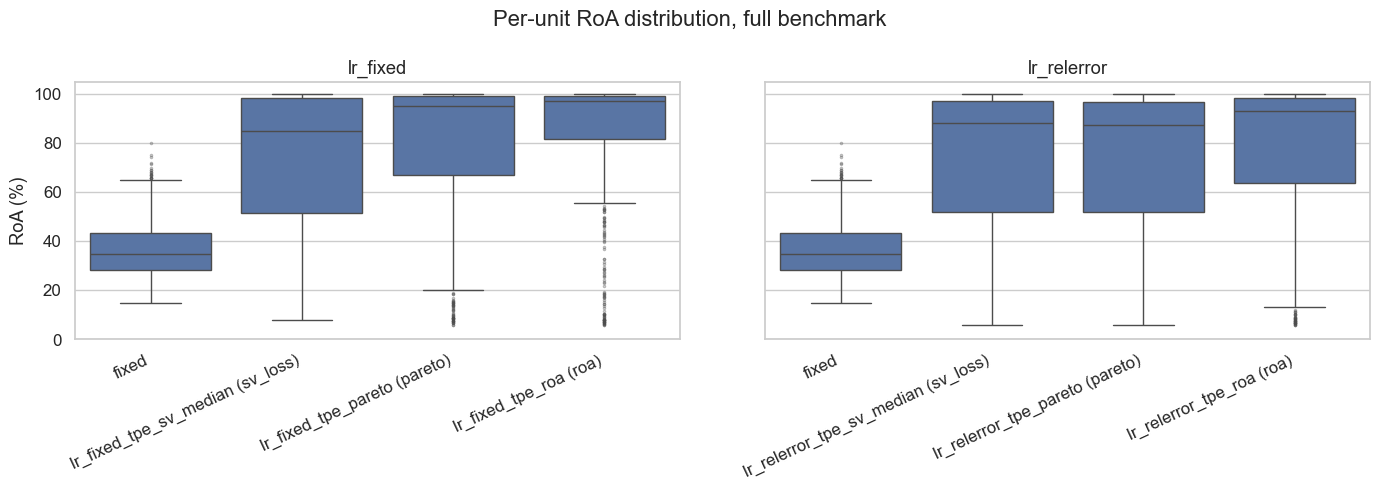

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, lr_token in zip(axs, ['lr_fixed', 'lr_relerror']):
    cfgs = [c for c in configs_present if c == 'fixed' or c.startswith(lr_token)]
    sub_df = df_roa[df_roa['config'].isin(cfgs)]
    sns.boxplot(data=sub_df, x='config', y='roa_pct', order=cfgs,
                flierprops=dict(marker='.', markersize=3, alpha=0.4), ax=ax)
    ax.set(xlabel='', ylabel='RoA (%)', title=lr_token, ylim=(0, 105))
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_ha('right')
plt.suptitle('Per-unit RoA distribution, full benchmark')
plt.tight_layout()
plt.show()

### Reading this

`fixed` is the no-adaptation reference -- every adapted config should clear it by a wide margin;
if one doesn't, that's the first thing worth checking (a broken apply pass, not a real search
result). `roa` is a ground-truth-informed upper bound (it scores trials directly against RoA
rather than a training-loss proxy, so it isn't achievable without ground truth outside
simulation) -- compare `sv_loss` against `pareto` for the realistic single-vs-multi-objective
comparison, and treat `roa`'s margin over both as roughly "how much headroom a better loss
proxy could recover." Treat this as one seed's worth of evidence (`random_seed=42`, 50 trials
per branch, not repeated) -- informative, but not proof any ordering holds beyond this
particular draw.